# Bias–Variance และ Learning Curves
งานนี้แบ่งเป็น 3 ส่วนตามโจทย์ รันทีละเซลล์จากบนลงล่างได้เลย

- **ส่วนที่ 1–2:** หา bias และ variance ด้วย *analytical* และ *simulation* ของ 3 แบบจำลอง
  (ค่าคงที่ `h=b`, เชิงเส้น `h=ax+b`, เชิงเส้นผ่านจุดกำเนิด `h=ax`)
  กับฟังก์ชันเป้าหมาย `sin(πx)` และ `x²` สุ่มข้อมูล 2 จุดจาก `U[-1,1]`
- **ส่วนที่ 3:** learning curves เปรียบเทียบ 3 แบบจำลอง + ทดลองใส่ noise

> ใช้ **least squares** (`np.linalg.lstsq`) ในการ fit แบบจำลอง (ไม่ใช้ gradient descent)

## 0) Import ไลบรารีและตั้งค่าตัวสุ่ม

In [1]:
# numpy       : คำนวณเวกเตอร์/เมทริกซ์ และสุ่มตัวเลข
# matplotlib  : วาดกราฟ
# scipy.integrate : ใช้อินทิเกรตเชิงตัวเลข (analytical bias/variance)
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

%matplotlib inline
# กำหนด seed ให้ผลการสุ่มซ้ำได้ทุกครั้งที่รัน (ส่วนที่ 1-2 ใช้ seed=42)
rng = np.random.default_rng(42)

## ส่วน A) TOOLKIT — 3 แบบจำลอง fit ด้วย least squares (`np.linalg.lstsq`)
ตกลง convention ของเวกเตอร์พารามิเตอร์ `theta` ให้เหมือนกันทั้งไฟล์:
`theta = (a, b)` โดย `theta[0] = a` (ความชัน / slope), `theta[1] = b` (จุดตัดแกน / intercept)

ทุก `fit` รับ `(x, y)` 1 มิติ แล้วคืน `(a, b)` เสมอ — แบบจำลองไหนไม่มีพจน์นั้นค่าจะเป็น 0
(`lstsq` แก้ least squares ซึ่งให้ผลเท่ากับ normal equation)

In [2]:
def fit_const(x, y):
    # แบบจำลองค่าคงที่ h(x)=b : ฟีเจอร์มีแต่คอลัมน์ 1 (m,1)
    # lstsq กับคอลัมน์ 1 ล้วน จะได้ b = ค่าเฉลี่ยของ y นั่นเอง
    b = np.linalg.lstsq(np.ones((len(x), 1)), y, rcond=None)[0]
    return np.array([0.0, b[0]])              # คืน (a=0, b) เพราะไม่มีความชัน

def fit_linear(x, y):
    # แบบจำลองเชิงเส้น h(x)=a*x+b : ฟีเจอร์ [x, 1] เพื่อหาทั้ง a และ b
    X = np.column_stack([x, np.ones(len(x))])
    return np.linalg.lstsq(X, y, rcond=None)[0]   # คืน (a, b)

def fit_linear_origin(x, y):
    # แบบจำลองเชิงเส้นผ่านจุดกำเนิด h(x)=a*x : ฟีเจอร์ [x] เท่านั้น (บังคับ b=0)
    a = np.linalg.lstsq(x.reshape(-1, 1), y, rcond=None)[0]
    return np.array([a[0], 0.0])              # คืน (a, b=0)

def predict(theta, x):
    """theta = (a, b)  ->  a*x + b"""
    return theta[0] * x + theta[1]            # ความชัน*x + จุดตัดแกน

## ส่วน B) รวม 3 แบบจำลอง + 2 ฟังก์ชันเป้าหมายไว้ใน dict
เก็บ `fit` ทั้งสามไว้ใน `MODELS` และฟังก์ชันเป้าหมายจริงไว้ใน `TARGETS`
เพื่อวนลูปเรียกใช้ทีละคู่ (เป้าหมาย × แบบจำลอง) แบบเดียวกันทั้งหมด

In [3]:
# รวมแบบจำลองไว้ใน dict เพื่อวนลูปเรียกใช้แบบเดียวกัน (ชื่อ -> ฟังก์ชัน fit)
MODELS = {"constant":   fit_const,
          "linear":     fit_linear,
          "lin-origin": fit_linear_origin}

# ฟังก์ชันเป้าหมายจริง 2 แบบตามโจทย์ (สิ่งที่แบบจำลองพยายามเลียนแบบ)
TARGETS = {"sin(pi*x)": lambda x: np.sin(np.pi * x),   # คลื่นไซน์
           "x^2":       lambda x: x ** 2}              # พาราโบลา

## ส่วน C) BIAS–VARIANCE  (ตอบส่วนที่ 1–2 ของโจทย์)

นิยามที่ใช้:
- `g_D(x)` = แบบจำลองที่ fit จากชุดข้อมูล D หนึ่งชุด
- `gbar(x) = E_D[g_D(x)]` = แบบจำลองเฉลี่ยเหนือชุดข้อมูลทั้งหมด
- `bias = E_x[(gbar(x) − f(x))²]`
- `variance = E_x[ E_D[(g_D(x) − gbar(x))²] ]`

### C.1 นิยามฟังก์ชัน simulation (Monte Carlo) และ analytical (อินทิเกรตตรง)

In [4]:
def simulate(f, fit, M=100_000, N=2):
    """วิธี SIMULATION (Monte Carlo): fit ชุดข้อมูล M ชุด แล้วประมาณ bias, variance"""
    # วนสุ่ม M รอบ: แต่ละรอบสุ่ม x จำนวน N จุดจาก U[-1,1] แล้ว fit ได้ (a,b)
    # เก็บทุกรอบเป็นเมทริกซ์ W ขนาด (M, 2)  (ไม่มี noise ในส่วนนี้)
    W = np.array([fit(x := rng.uniform(-1, 1, N), f(x)) for _ in range(M)])
    xs = np.linspace(-1, 1, 1001)                 # กริดจุด x ไว้เฉลี่ยผลเหนือช่วง [-1,1]
    # ค่าทำนายบนกริด: G[m] = a_m * xs + b_m  ->  เมทริกซ์ (M, 1001)
    G = np.outer(W[:, 0], xs) + W[:, 1:2]
    gbar = G.mean(axis=0)                          # gbar(x) = แบบจำลองเฉลี่ยเหนือทุกชุดข้อมูล
    bias = np.mean((gbar - f(xs)) ** 2)            # bias = เฉลี่ยกำลังสองของ (gbar - f) เหนือ x
    var  = np.mean(G.var(axis=0))                  # variance = var เหนือ D แล้วเฉลี่ยเหนือ x
    return bias, var, xs, gbar, G                  # คืนค่าทั้งหมด (รวมข้อมูลไว้วาดกราฟ)


def analytical(f, fit):
    """วิธี ANALYTICAL: เฉลี่ย a, b เหนือ (x1,x2) ~ U[-1,1]^2 (ความหนาแน่นร่วม 1/4)"""
    # ฟังก์ชันช่วย: fit จากข้อมูล 2 จุด (x1,x2) แล้วคืนพารามิเตอร์ (a, b)
    ab = lambda x1, x2: fit(p := np.array([x1, x2]), f(p))
    # ค่าคาดหวัง E[g(a,b)] = อินทิเกรตสองชั้นเหนือ (x1,x2) คูณความหนาแน่นร่วม 1/4
    E = lambda g: integrate.dblquad(
        lambda x2, x1: g(*ab(x1, x2)) * 0.25, -1, 1, -1, 1)[0]

    Ea, Eb = E(lambda a, b: a), E(lambda a, b: b)                 # ค่าคาดหวังของ a และ b
    Ea2, Eb2, Eab = E(lambda a, b: a*a), E(lambda a, b: b*b), E(lambda a, b: a*b)  # โมเมนต์ที่ 2

    # bias = อินทิเกรต (gbar = Ea*x+Eb ลบ f(x)) ยกกำลังสอง คูณความหนาแน่น 1/2
    bias = integrate.quad(lambda x: (Ea*x + Eb - f(x))**2 * 0.5, -1, 1)[0]
    # variance = อินทิเกรต ( E[g(x)^2] - (E[g(x)])^2 ) คูณความหนาแน่น 1/2
    var  = integrate.quad(lambda x: (Ea2*x**2 + 2*Eab*x + Eb2
                                     - (Ea*x + Eb)**2) * 0.5, -1, 1)[0]
    return bias, var

### C.2 รันทุกคู่ (ฟังก์ชันเป้าหมาย × แบบจำลอง) และวาดรูป
แต่ละกราฟแสดง: เส้น g_D ตัวอย่าง (สีเทา), แถบ gbar ± sd (ฟ้า), f(x) จริง (เขียว), gbar(x) (แดงประ)

> เซลล์นี้ตั้ง `M=100_000` อาจใช้เวลาหลายสิบวินาที ถ้าอยากเร็วปรับ `M` ให้น้อยลงได้

target     model       | bias(ana) bias(sim) |  var(ana)  var(sim) |    Eout
------------------------------------------------------------------------------
sin(pi*x)  constant    |    0.5000    0.4995 |    0.2500    0.2494 |  0.7500
sin(pi*x)  linear      |    0.2067    0.2063 |    1.6763    1.6641 |  1.8830
sin(pi*x)  lin-origin  |    0.2706    0.2732 |    0.2366    0.2380 |  0.5072
x^2        constant    |    0.0889    0.0892 |    0.0444    0.0444 |  0.1333
x^2        linear      |    0.2000    0.2011 |    0.3333    0.3340 |  0.5333
x^2        lin-origin  |    0.2000    0.2008 |    0.1149    0.1153 |  0.3149


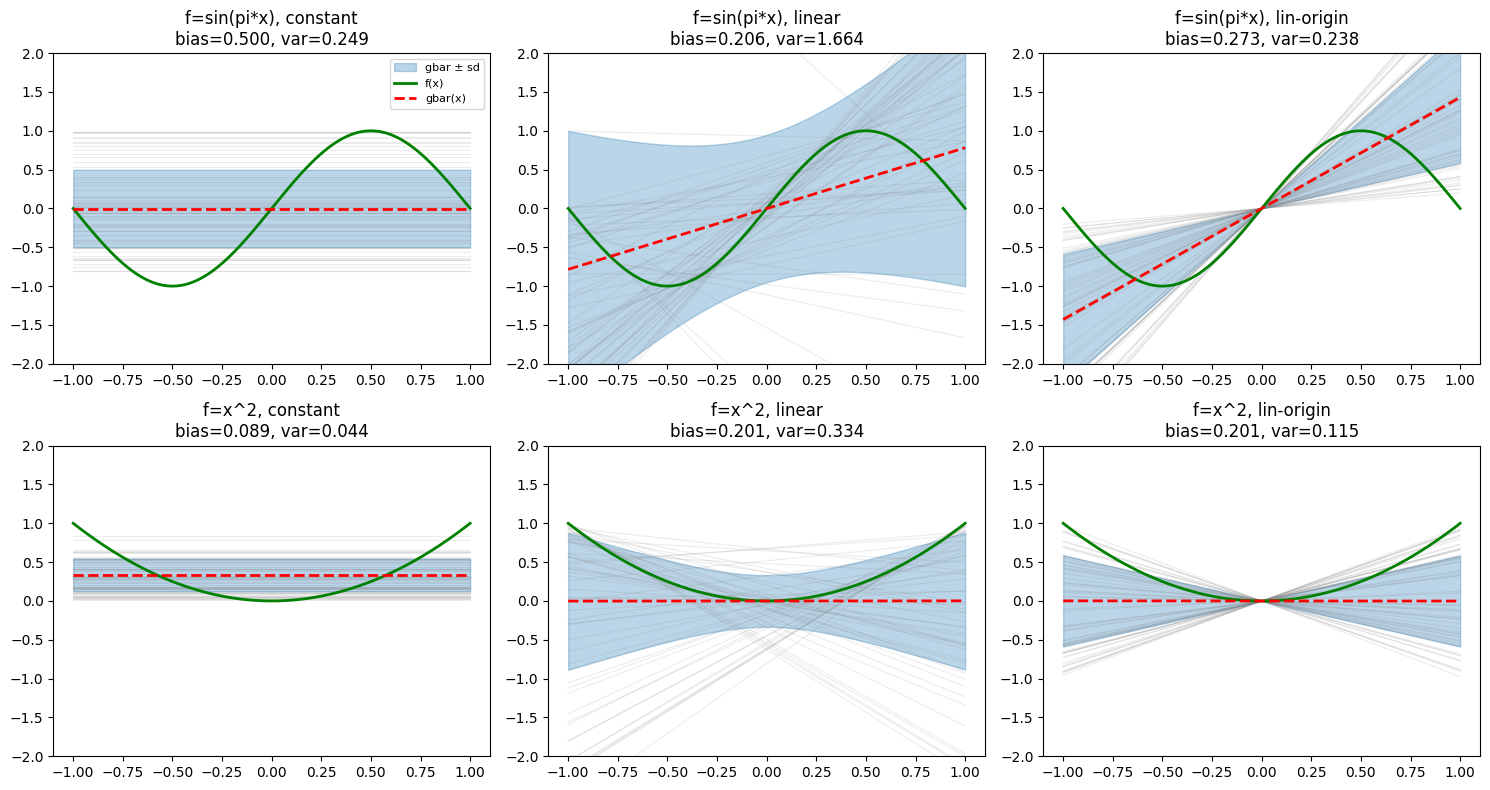

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))    # ตาราง 2 แถว(เป้าหมาย) x 3 คอลัมน์(แบบจำลอง)

# หัวตารางผลลัพธ์ (เทียบ analytical กับ simulation)
print(f"{'target':<10} {'model':<11} | {'bias(ana)':>9} {'bias(sim)':>9} | "
      f"{'var(ana)':>9} {'var(sim)':>9} | {'Eout':>7}")
print("-" * 78)

for i, (fname, f) in enumerate(TARGETS.items()):        # วนแต่ละฟังก์ชันเป้าหมาย (แถว i)
    for j, (mname, fit) in enumerate(MODELS.items()):   # วนแต่ละแบบจำลอง (คอลัมน์ j)
        b_ana, v_ana = analytical(f, fit)               # ค่าจากสูตร (อินทิเกรต)
        b_sim, v_sim, xs, gbar, G = simulate(f, fit)    # ค่าจากการจำลอง (Monte Carlo)
        # พิมพ์ผลเทียบสองวิธี + Eout = bias + variance
        print(f"{fname:<10} {mname:<11} | {b_ana:9.4f} {b_sim:9.4f} | "
              f"{v_ana:9.4f} {v_sim:9.4f} | {b_ana+v_ana:7.4f}")

        ax = axes[i, j]
        for g in G[:60]:                                # เส้นตัวอย่าง 60 เส้นจาง ๆ
            ax.plot(xs, g, color="gray", alpha=0.15, lw=0.8)
        sd = G.std(axis=0)
        ax.fill_between(xs, gbar - sd, gbar + sd, color="tab:blue",
                        alpha=0.3, label="gbar ± sd")
        ax.plot(xs, f(xs), "g", lw=2, label="f(x)")     # ฟังก์ชันเป้าหมายจริง
        ax.plot(xs, gbar, "r--", lw=2, label="gbar(x)") # แบบจำลองเฉลี่ย
        ax.set_ylim(-2, 2)
        ax.set_title(f"f={fname}, {mname}\nbias={b_sim:.3f}, var={v_sim:.3f}")
        if i == 0 and j == 0:
            ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("bias_variance.png", dpi=120)   # บันทึกรูป
plt.show()

## ส่วน D) LEARNING CURVES  (ตอบส่วนที่ 3 ของโจทย์)
เปรียบเทียบ 3 แบบจำลองว่าเมื่อเพิ่มจำนวนตัวอย่างฝึก N แล้ว error เปลี่ยนอย่างไร
และทดลองเพิ่มเติมด้วยการใส่สัญญาณรบกวน (noise ~ N(0, σ²))

### D.1 นิยามฟังก์ชัน learning curve
- `Ein`  = MSE บนชุดฝึก (เทียบกับ y ที่อาจมี noise) ผ่าน `predict(theta, x)`
- `Eout` = MSE เทียบ f จริง บน grid (ค่าคาดหวังของ error เหนือ x จริง ๆ)

> ส่วนนี้ตั้ง seed ใหม่เป็น `0` (แยกจากส่วน bias–variance ที่ใช้ 42)

In [6]:
rng = np.random.default_rng(0)                     # ตั้ง seed=0 สำหรับส่วน learning curves

def learning_curve(f, fit, Ns, sigma=0.0, trials=3000):
    """คืน (Ein เฉลี่ย, Eout เฉลี่ย) ต่อแต่ละค่า N ใน Ns
       ทำซ้ำ trials รอบต่อ N เพื่อเฉลี่ยความผันผวนจากการสุ่ม"""
    xs = np.linspace(-1, 1, 400)                   # กริดจุด x ไว้วัด Eout
    Ein, Eout = [], []                             # เก็บ error เฉลี่ยของแต่ละขนาดชุดฝึก N
    for N in Ns:
        ein = eout = 0.0
        for _ in range(trials):
            x = rng.uniform(-1, 1, N)              # สุ่มชุดฝึก N จุด
            y = f(x) + sigma * rng.standard_normal(N)   # ค่าจริง + noise แบบเกาส์เซียน
            theta = fit(x, y)                      # fit ได้พารามิเตอร์ (a, b)
            ein  += np.mean((predict(theta, x) - y) ** 2)       # Ein: error บนชุดฝึก (เทียบ y)
            eout += np.mean((predict(theta, xs) - f(xs)) ** 2)  # Eout: error เทียบ f จริงบนกริด
        Ein.append(ein / trials)
        Eout.append(eout / trials)
    return np.array(Ein), np.array(Eout)

### D.2 วาด learning curves (ไม่มี noise เทียบกับ มี noise)
เส้นทึบ = Eout, เส้นประ = Ein, เส้นจุด = noise floor `σ²`
เปลี่ยน `fname` เป็น `"x^2"` เพื่อดูอีกฟังก์ชันเป้าหมายได้

sigma=0.0  constant    Eout(N=2)=0.752  Eout(N=60)=0.507
sigma=0.0  linear      Eout(N=2)=1.927  Eout(N=60)=0.206
sigma=0.0  lin-origin  Eout(N=2)=0.512  Eout(N=60)=0.202
sigma=0.3  constant    Eout(N=2)=0.798  Eout(N=60)=0.509
sigma=0.3  linear      Eout(N=2)=50020.331  Eout(N=60)=0.209
sigma=0.3  lin-origin  Eout(N=2)=0.734  Eout(N=60)=0.204


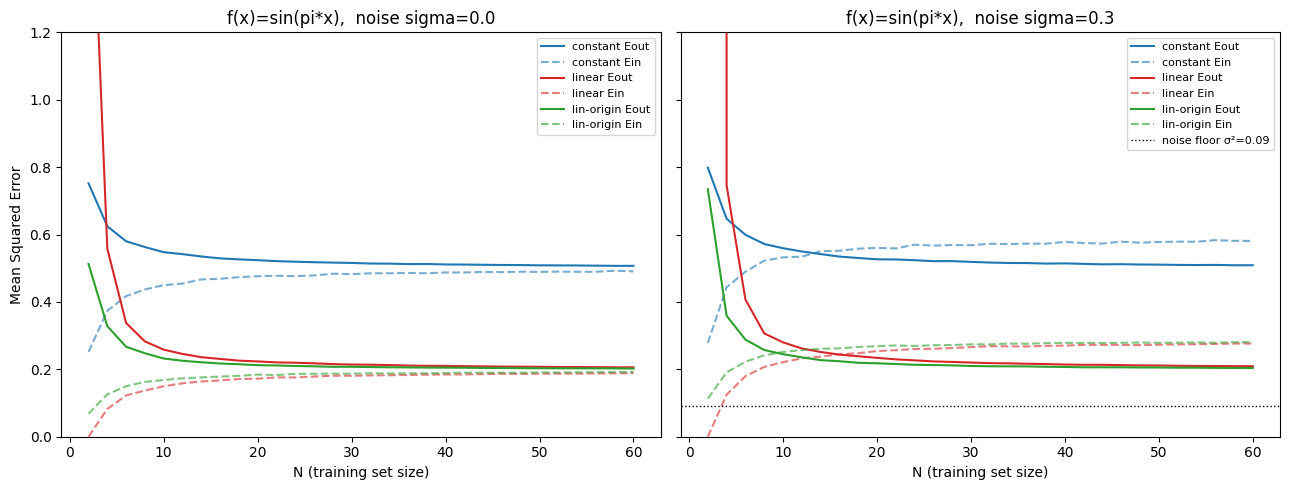

In [7]:
fname = "sin(pi*x)"        # เปลี่ยนเป็น "x^2" ได้
f = TARGETS[fname]
Ns = np.arange(2, 61, 2)   # จำนวนตัวอย่างฝึก 2, 4, ..., 60
sigmas = [0.0, 0.3]        # ซ้าย = ไม่มี noise, ขวา = มี noise sigma=0.3
colors = {"constant": "tab:blue", "linear": "tab:red", "lin-origin": "tab:green"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)  # 2 กราฟข้างกัน ใช้แกน y ร่วม
for ax, sigma in zip(axes, sigmas):
    for name, fit in MODELS.items():
        Ein, Eout = learning_curve(f, fit, Ns, sigma)
        ax.plot(Ns, Eout, "-",  color=colors[name], label=f"{name} Eout")   # เส้นทึบ = Eout
        ax.plot(Ns, Ein,  "--", color=colors[name], alpha=0.6,
                label=f"{name} Ein")                                        # เส้นประ = Ein
        print(f"sigma={sigma}  {name:<10}  "
              f"Eout(N=2)={Eout[0]:.3f}  Eout(N=60)={Eout[-1]:.3f}")
    if sigma > 0:
        # เส้นอ้างอิงระดับ noise (noise floor)
        ax.axhline(sigma**2, color="k", ls=":", lw=1, label=f"noise floor σ²={sigma**2:.2f}")
    ax.set_title(f"f(x)={fname},  noise sigma={sigma}")
    ax.set_xlabel("N (training set size)")
    ax.set_ylim(0, 1.2)
    ax.legend(fontsize=8)
axes[0].set_ylabel("Mean Squared Error")
plt.tight_layout()
plt.savefig("learning_curves.png", dpi=120)
plt.show()